In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from math import sqrt, pi
from numpy import exp

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.labelsize": 28,
    "axes.titlesize": 28,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.direction": 'in',
    "ytick.direction": 'in',
    "xtick.top": False,
    "ytick.right": False,
    "legend.frameon": False,
    "legend.handlelength": 2.0,
    "legend.handletextpad": 0.5,
    "legend.borderaxespad": 0.6,
    "legend.fontsize": 28,
})

In [3]:
a1 = np.array([1 + sqrt(2), 0.0])
a2 = np.array([0.0, 1 + sqrt(2)])
τ = 1.0

Γ = np.array([0.0, 0.0])
X = np.array([0.5, 0])
M = np.array([0.5, 0.5])

b = 2 * pi * np.linalg.inv(np.array([a1, a2])).T
Γ, X, M = [Γ @ b, X @ b, M @ b]

path = [Γ, X, M, Γ]
labels = [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$']
n_k = 500

klist, xticks = [], [0]
for i in range(len(path) - 1):
    segment = [path[i] + (path[i+1] - path[i]) * j / n_k for j in range(n_k)]
    klist.extend(segment)
    xticks.append(len(klist))

xvals = np.arange(len(klist))

In [4]:
def ham(k):
    μ, t, Θ = 0, 1, 0.0 * pi
    k_a1, k_a2 = k @ a1, k @ a2
    return np.array([
        [μ, t * exp(1j * Θ), t * exp(1j * k_a2) + τ, t * exp(-1j * Θ)],
        [t * exp(-1j * Θ), μ, t * exp(1j * Θ), t * exp(-1j * k_a1) + τ],
        [t * exp(-1j * k_a2) + τ, t * exp(-1j * Θ), μ, t * exp(1j * Θ)],
        [t * exp(1j * Θ), t * exp(1j * k_a1) + τ, t * exp(-1j * Θ), μ]
    ])


bands = np.array([np.sort(np.linalg.eigvalsh(ham(k))) for k in klist])

Nk = 200
eta = 0.01
E_vals = np.linspace(-4, 4, 1000)
dos = np.zeros_like(E_vals)

kx_vals = 1 / a1[0] * np.linspace(-pi, pi, Nk)
ky_vals = 1 / a2[1] * np.linspace(-pi, pi, Nk)

for kx, ky in product(kx_vals, ky_vals):
    eigvals = np.linalg.eigvalsh(ham(np.array([kx, ky])))
    for E in eigvals:
        dos += np.exp(-((E_vals - E)**2) / (2*eta**2)) / (eta*np.sqrt(2*pi))
dos /= Nk**2

delta_E = E_vals[1] - E_vals[0]
n_vals = np.cumsum(dos) * delta_E
n_vals = 2*(n_vals - n_vals.min())/(n_vals.max() - n_vals.min())

Text(-0.15, 1.1, '(a)')

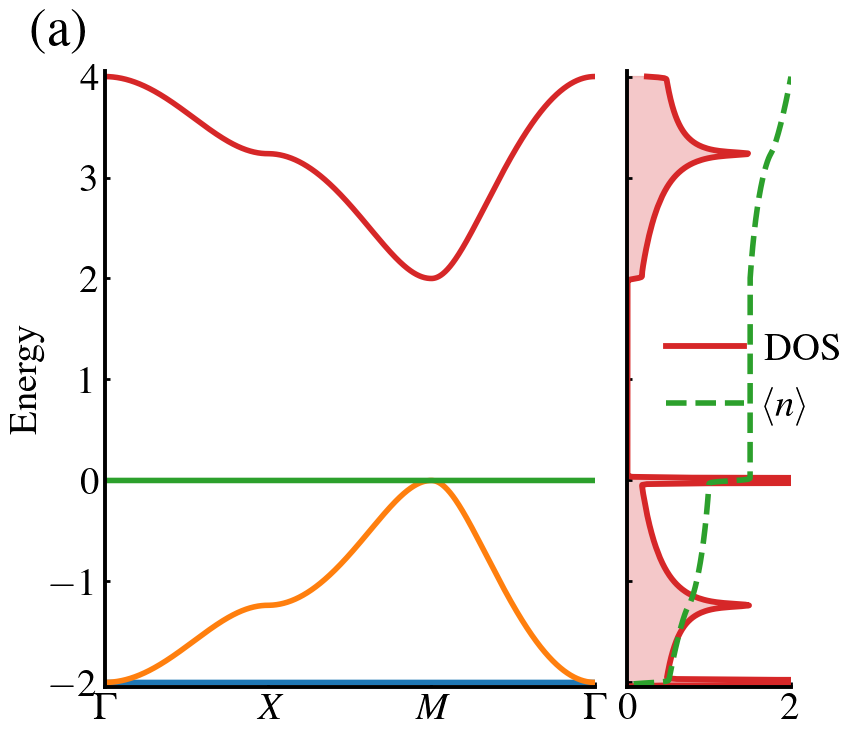

In [5]:
fig = plt.figure(figsize=(30, 8))
outer = fig.add_gridspec(1, 3, width_ratios=[2.75, 2.6, 2.5], wspace=0.28)
gs_a = outer[0].subgridspec(1, 2, width_ratios=[3, 1], wspace=0.1)
axA_band = fig.add_subplot(gs_a[0])
axA_dos = fig.add_subplot(gs_a[1], sharey=axA_band)


for i in range(bands.shape[1]):
    axA_band.plot(bands[:, i], linewidth=4.0)

axA_band.set_xticks(xticks)
axA_band.set_xticklabels(labels)
axA_band.set_ylabel("Energy")
axA_band.set_ylim(-2.05, 4.05)
axA_band.set_xlim(0, len(klist))
axA_band.spines['top'].set_visible(False)
axA_band.spines['right'].set_visible(False)

axA_dos.plot(dos, E_vals, color='tab:red', linewidth=4.2, label="DOS")
axA_dos.fill_betweenx(E_vals, dos, color='tab:red', alpha=0.25)
axA_dos.plot(n_vals, E_vals, '--', color='tab:green',
             linewidth=4.0, label=r'$\langle n\rangle$')
axA_dos.set_xlim(0, 2.0)
axA_dos.tick_params(labelleft=False)
axA_dos.spines['top'].set_visible(False)
axA_dos.spines['right'].set_visible(False)
axA_dos.legend()

axA_band.text(-0.15, 1.1, "(a)", transform=axA_band.transAxes,
              fontsize=38, va="top")

In [6]:
gs_b = outer[1].subgridspec(2, 2, hspace=0.18, wspace=0.12)
axes_b = [fig.add_subplot(gs_b[i, j]) for i in range(2) for j in range(2)]


def ham_b(k, τ):
    μ, t, Θ = 0, 1, 0.0 * pi
    k1, k2 = k @ a1, k @ a2
    return np.array([
        [μ, t*exp(1j*Θ), t*exp(1j*k2)+τ, t*exp(-1j*Θ)],
        [t*exp(-1j*Θ), μ, t*exp(1j*Θ), t*exp(-1j*k1)+τ],
        [t*exp(-1j*k2)+τ, t*exp(-1j*Θ), μ, t*exp(1j*Θ)],
        [t*exp(1j*Θ), t*exp(1j*k1)+τ, t*exp(-1j*Θ), μ]
    ])


tau_vals = [0.0, 0.25, 0.5, 0.75]
band_colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

In [7]:
for ax, τ in zip(axes_b, tau_vals):
    bands = np.array([np.linalg.eigvalsh(ham_b(k, τ)) for k in klist]).T
    for i, band in enumerate(bands):
        ax.plot(xvals, band, color=band_colors[i], linewidth=3.5)

    ax.set_xticks(xticks)
    ax.set_xticklabels(labels if ax in axes_b[2:] else ['']*4)
    ax.set_ylim(-3, 4)
    ax.text(0.5, 0.6, rf"$t_2={τ}$",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=28)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes_b[0].set_ylabel("Energy")
axes_b[2].set_ylabel("Energy")

axes_b[0].text(-0.3, 1.2, "(b)", transform=axes_b[0].transAxes,
               fontsize=38, va="top")

Text(-0.3, 1.2, '(b)')

In [8]:
axC = fig.add_subplot(outer[2])

eta = 0.0075


def ham_c(k, t2):
    k1 = k @ a1
    k2 = k @ a2
    return np.array([
        [0, exp(1j*0), exp(1j*k2)+t2, exp(-1j*0)],
        [exp(-1j*0), 0, exp(1j*0), exp(-1j*k1)+t2],
        [exp(-1j*k2)+t2, exp(-1j*0), 0, exp(1j*0)],
        [exp(1j*0), exp(1j*k1)+t2, exp(-1j*0), 0]
    ])


E_vals = np.linspace(-3, 5, 1200)
k_grid = np.array([[kx, ky] for kx, ky in product(kx_vals, ky_vals)])

t2_vals = [0.0, 0.25, 0.5, 0.75]
linestyles = ['-', '--', (0, (3, 1, 1, 1)), ':']

In [9]:
for t2, c, ls in zip(t2_vals, band_colors, linestyles):
    dos = np.zeros_like(E_vals)
    for k in k_grid:
        for E in np.linalg.eigvalsh(ham_c(k, t2)):
            dos += np.exp(-((E_vals - E)**2)/(2*eta**2)) / (eta*np.sqrt(2*pi))
    dos /= Nk**2
    axC.plot(E_vals, dos, color=c, linestyle=ls,
             linewidth=3.8, label=rf"$t_2={t2}$")

axC.set_xlabel("Energy")
axC.set_ylabel("Density of States")
axC.set_xlim(-3.25, 4)
axC.set_ylim(0, 8)
axC.legend(loc="upper right")
axC.spines['top'].set_visible(False)
axC.spines['right'].set_visible(False)

axC.text(-0.15, 1.1, "(c)", transform=axC.transAxes,
         fontsize=38, va="top")

Text(-0.15, 1.1, '(c)')

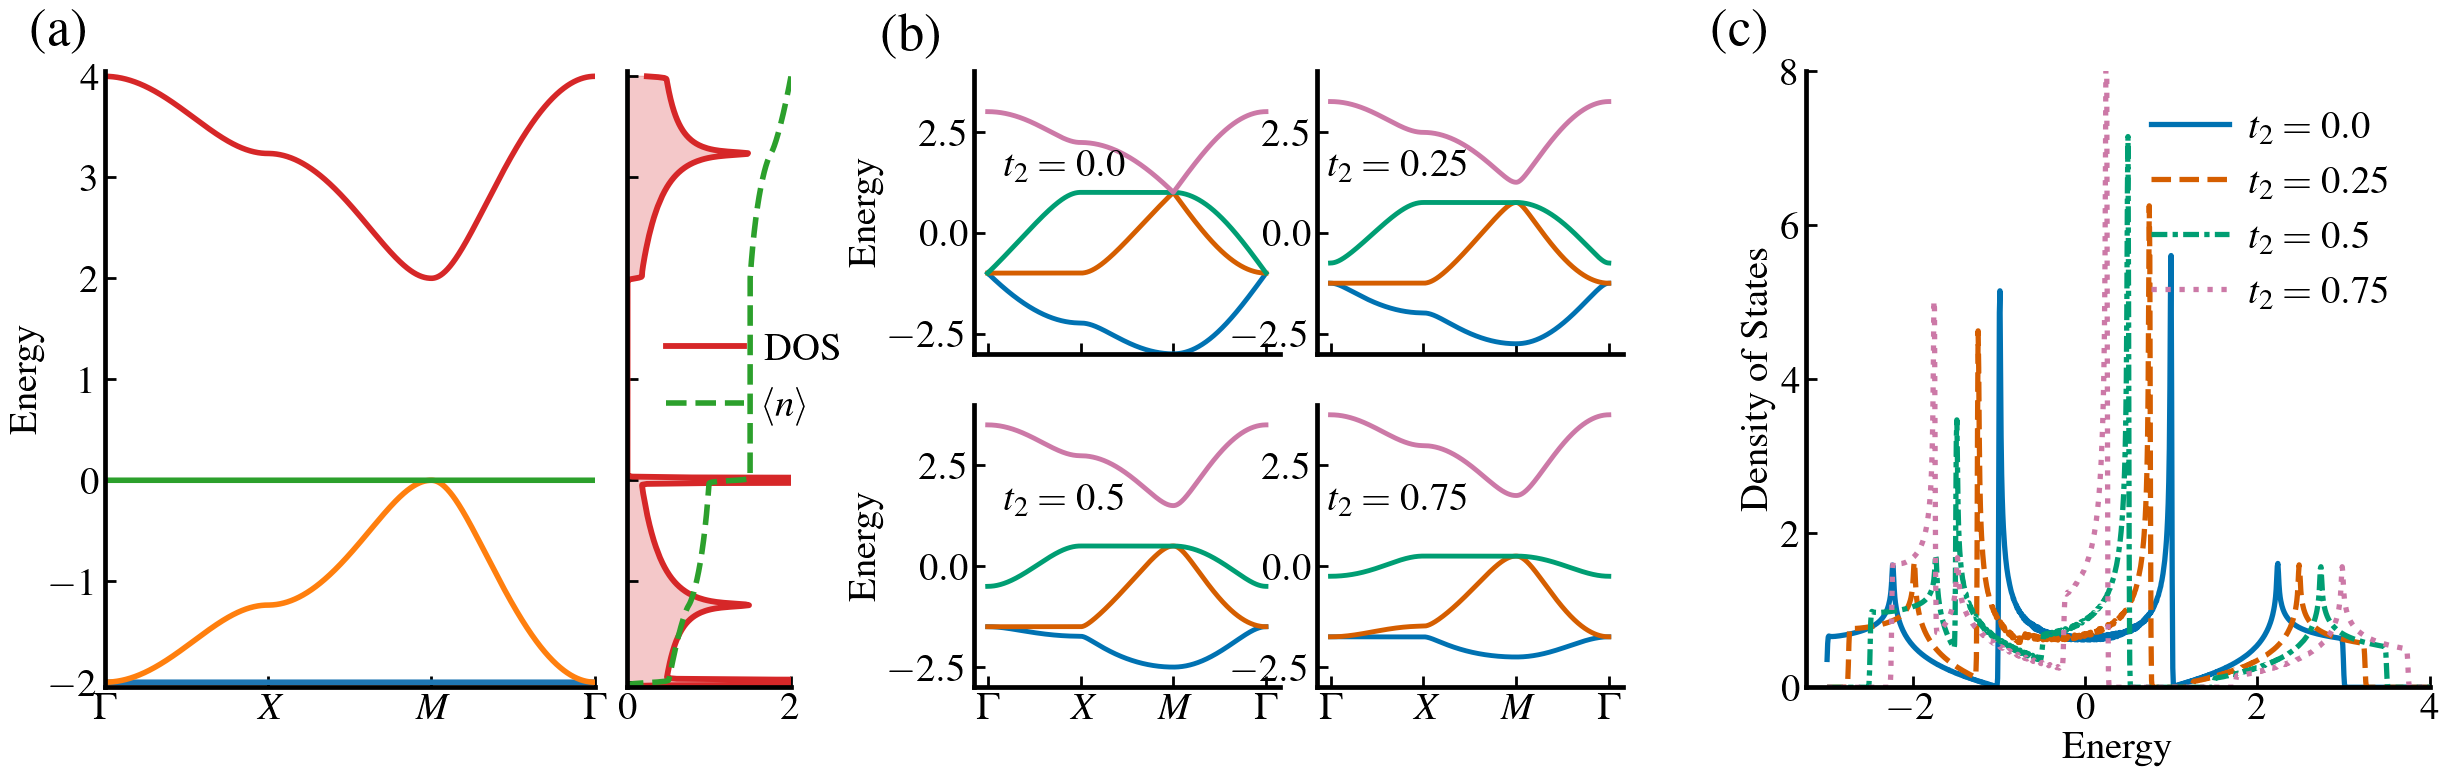

In [10]:
for ax in fig.axes:
    ax.tick_params(length=8)
    for spine in ax.spines.values():
        spine.set_linewidth(3.4)

# fig.savefig("images/so_bands_dos_n_t2.pdf", bbox_inches="tight")
display(fig)